In [1]:
%cd '/Users/voytek/GitHub/voytekresearch/spikeparam/'

/Users/voytek/GitHub/voytekresearch/spikeparam


In [1]:
# basic plotting imports
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

from tqdm.notebook import tqdm

import numpy as np
import pandas as pd

from neurodsp.spectral import compute_spectrum
from fooof import FOOOF

from scipy.signal import sosfiltfilt, butter, hilbert

from spikeparam.patch.fit import Spike, SpikeGroup
from statsmodels.tsa.ar_model import AutoReg

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(rc={'figure.figsize':(12,9)})
sns.set_style('whitegrid')
sns.set_style("whitegrid", {'axes.grid' : False})

/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_92993/1114693484.py:11: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOF
/Users/blancamartin/opt/anaconda3/lib/python3.9/site-packages/seaborn/cm.py:1582: MatplotlibDeprecationWarning: The register_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps.register(name)`` instead.
  mpl_cm.register_cmap(_name, _cmap)
/Users/blancamartin/opt/anaconda3/lib/python3.9/site-packages/seaborn/cm.py:1583: MatplotlibDeprecationWarning: The register_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps.register(name)`` instead.
  mpl_cm.

In [2]:
def butter_bandpass(data, fs, filt_freq, order):
    # make sure that the user provides two frequencies for bandpass filter
    try:
        # renormalize frequencies in Hz to fractional scale required by butter
        nyq = 0.5 * fs # nyquist frequency
        f0 = (filt_freq[0]/nyq)
        f1 = (filt_freq[1]/nyq)

        # highpass first
        sos = butter(order, f0, btype = 'high', analog=False, output='sos')
        y = sosfiltfilt(sos, data)

        # then lowpass
        sos = butter(order, f1, btype = 'low', analog=False, output='sos')
        y = sosfiltfilt(sos, y)
        
        return y
    
    except:
        print("filt_freq must have two frequencies for a bandpass filter")

# IAP vs. EAP vs. LFP features

In [3]:
# Load data
filedir = 'datasets/spe-1/EAP-Yes/c14/'

patch = np.load(filedir + 'patch_filt.npy')
npx   = np.load(filedir + 'npx_filt.npy')
lfp   = np.load(filedir + 'lfp_filt.npy')

fs_patch = 50023.88925263
fs_npx   = 30000
fs_lfp   = 2500

# Prevents edges issues by removing spikes withing .5s from start/end
patch[:int(fs_patch//2)] = 0
patch[-int(fs_patch//2):] = 0


FileNotFoundError: [Errno 2] No such file or directory: 'datasets/spe-1/EAP-Yes/c14/patch_filt.npy'

In [37]:
np.size(patch)/fs_patch, np.size(npx)/fs_npx, np.size(lfp)/fs_lfp

(1080.0455703703503, 1080.0453666666667, 1080.0448)

In [38]:
	# •	IAP params									✓
	# •	EAP spike amp								✓
	# •	pre-IAP LFP exponent, mean, std				✓
	# •	pre-IAP LFP delta power						✓
	# •	pre-IAP LFP gamma power						✓
	# •	gamma phase at time of spike initiation		✓
	# •	delta phase at time of spike initiation		✓
	# •	post-IAP LFP delta power					✓
	# •	post-IAP LFP gamma power					✓

In [39]:
filt_delta = butter_bandpass(lfp, fs=fs_lfp, filt_freq=[0.1, 4.0], order=12)
pw_delta = np.abs(hilbert(filt_delta))
ph_delta = np.angle(hilbert(filt_delta))

filt_gamma = butter_bandpass(lfp, fs=fs_lfp, filt_freq=[30, 70], order=4)
pw_gamma = np.abs(hilbert(filt_gamma))
ph_gamma = np.angle(hilbert(filt_gamma))


patch = (patch - np.mean(patch)) / np.std(patch)
npx = (npx - np.mean(npx)) / np.std(npx)
pw_gamma = (pw_gamma - np.mean(pw_gamma)) / np.std(pw_gamma)

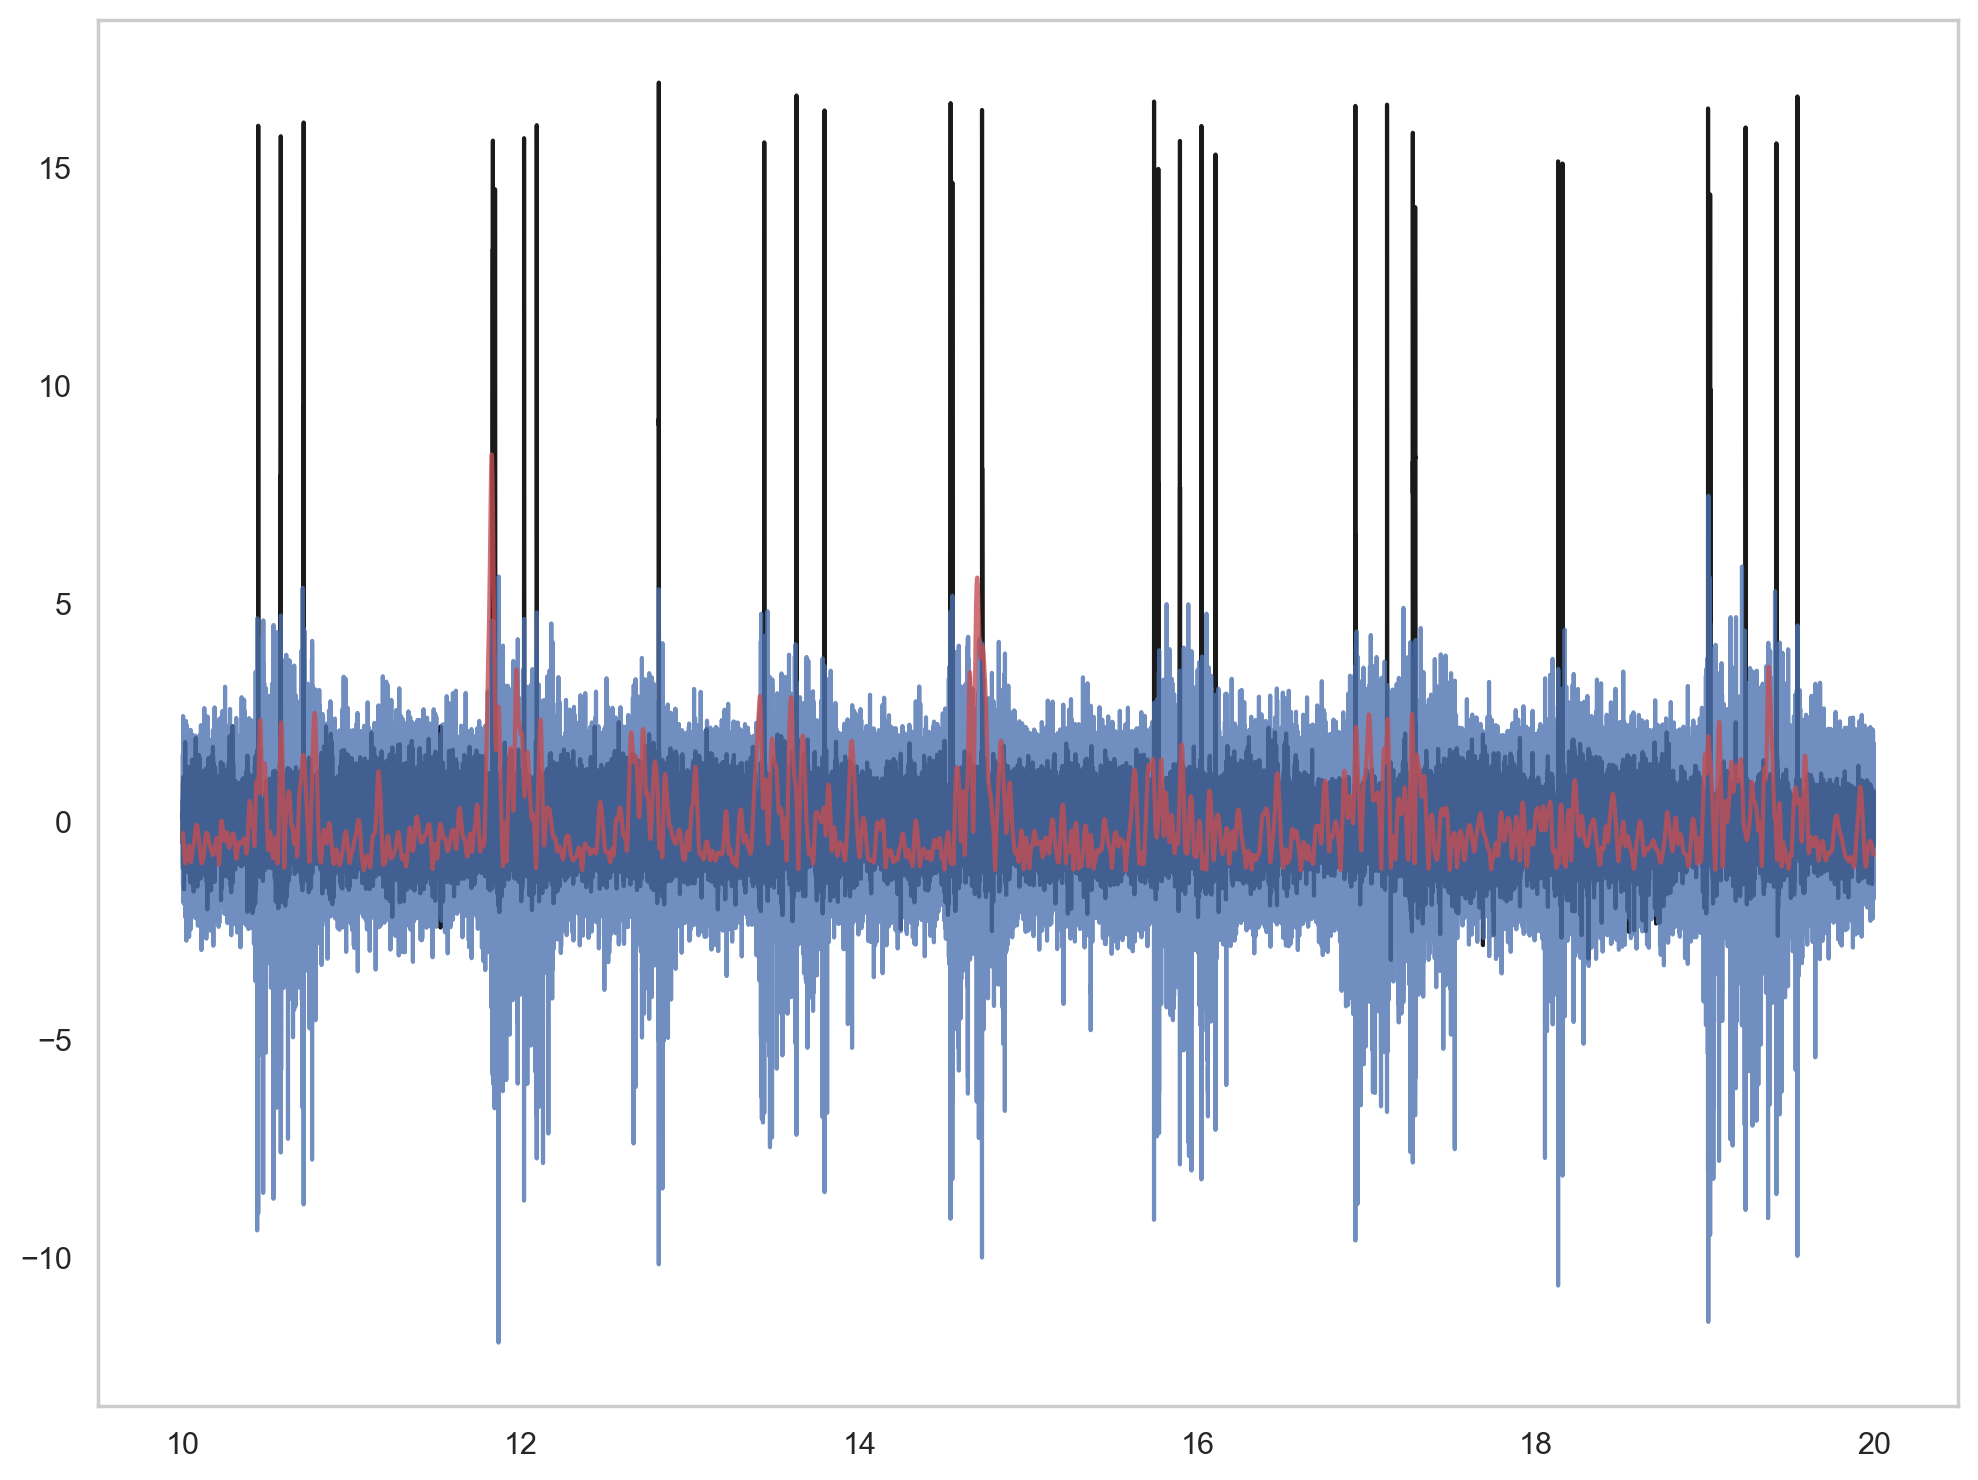

In [42]:
start = 0
end = 1000

t_patch = np.linspace(0, patch.size/fs_patch, patch.size)
t_npx = np.linspace(0, npx.size/fs_npx, npx.size)
t_gam = np.linspace(0, pw_gamma.size/fs_lfp, pw_gamma.size)

s = 10
e = 20

plt.plot(t_patch[(s*int(fs_patch)):(e*int(fs_patch))], patch[(s*int(fs_patch)):(e*int(fs_patch))], 'k')
plt.plot(t_npx[(s*fs_npx):(e*fs_npx)], npx[(s*fs_npx):(e*fs_npx)], 'b', alpha=0.8)
plt.plot(t_gam[(s*fs_lfp):(e*fs_lfp)], pw_gamma[(s*fs_lfp):(e*fs_lfp)], 'r', alpha=0.8)
plt.show()

In [7]:
# Custom spike features to compare to patch features
def npx_features(sig, fs):
    params = np.array([sig.min()])
    return params

# Custom LFP aperiodic features to compare to patch features
def lfp_aper_features(sig, fs):
    
    # Spectral
    f, p = compute_spectrum(sig, fs, f_range=(10, 150), nperseg=200)
    
    fm = FOOOF(max_n_peaks=0, peak_width_limits = [0.5, 10], verbose=False)
    fm.fit(f, p)
    
    ap_params = fm.get_params('aperiodic')
    rsq = fm.r_squared_
    
    # Autoregressive
    ar = AutoReg(sig, 3)
    ar = ar.fit()
    ar0, ar1, ar2 = ar.params[1:]

    params = np.array([sig.mean(), sig.std(), *ap_params, rsq, ar0, ar1, ar2])
    
    return params

# Custom LFP power features to compare to patch features
def lfp_pow_features(sig, fs):
    params = np.array([sig.mean()])
    
    return params

# Custom LFP phase features to compare to patch features
def lfp_ph_features(sig, fs):
    params = np.array([sig[0]])
    
    return params


In [8]:
# Initialize
sp = Spike(thresh_amp=200, window_length=(2, 5), smooth_frac=.1)

# Queue spike features
sp.alt(
    npx, fs_npx, npx_features, n_jobs=1, ref='peak', window_length=(2., 5.), queue=True,
    param_keys=['eap_peak']
)
# Fit
sp.fit(patch, fs_patch, n_jobs=-1, progress=tqdm)
full_eap_spikes = sp.alt_windows

# Queue LFP aperiodic features
sp.alt(
    lfp, fs_lfp, lfp_aper_features, n_jobs=1, ref='inflection', window_length=(100., 0.), queue=True,
    param_keys=[
        'lfp_mean', 'lfp_std', 'offset', 'exponent', 'rsq', 'ar0', 'ar1', 'ar2',
    ]
)
# Fit
sp.fit(patch, fs_patch, n_jobs=-1, progress=tqdm)

# Queue LFP pre-delta power features
sp.alt(
    pw_delta, fs_lfp, lfp_pow_features, n_jobs=1, ref='inflection', window_length=(100., 0.), queue=True,
    param_keys=['pre_delta_pow']
)
# Fit
sp.fit(patch, fs_patch, n_jobs=-1, progress=tqdm)

# Queue LFP pre-gamma power features
sp.alt(
    pw_gamma, fs_lfp, lfp_pow_features, n_jobs=1, ref='inflection', window_length=(100., 0.), queue=True,
    param_keys=['pre_gamma_pow']
)
# Fit
sp.fit(patch, fs_patch, n_jobs=-1, progress=tqdm)

# Queue LFP delta phase at onset features
sp.alt(
    ph_delta, fs_lfp, lfp_ph_features, n_jobs=1, ref='inflection', window_length=(1., 0.), queue=True,
    param_keys=['pre_delta_ph']
)
# Fit
sp.fit(patch, fs_patch, n_jobs=-1, progress=tqdm)

# Queue LFP gamma phase at onset features
sp.alt(
    ph_gamma, fs_lfp, lfp_ph_features, n_jobs=1, ref='inflection', window_length=(1., 0.), queue=True,
    param_keys=['pre_gamma_ph']
)
# Fit
sp.fit(patch, fs_patch, n_jobs=-1, progress=tqdm)

# Queue LFP post-delta power features
sp.alt(
    pw_delta, fs_lfp, lfp_pow_features, n_jobs=1, ref='exp_end', window_length=(0., 100.), queue=True,
    param_keys=['post_delta_pow']
)
# Fit
sp.fit(patch, fs_patch, n_jobs=-1, progress=tqdm)

# Queue LFP post-gamma power features
sp.alt(
    pw_gamma, fs_lfp, lfp_pow_features, n_jobs=1, ref='exp_end', window_length=(0., 100.), queue=True,
    param_keys=['post_gamma_pow']
)
# Fit
sp.fit(patch, fs_patch, n_jobs=-1, progress=tqdm)

df = sp.df_features
df.to_csv(filedir + 'pd_features.csv')
np.save(filedir + 'full_eap_spikes.npy', full_eap_spikes)

  0%|          | 0/5561 [00:00<?, ?it/s]

  0%|          | 0/5561 [00:00<?, ?it/s]

  0%|          | 0/5561 [00:00<?, ?it/s]

  0%|          | 0/5561 [00:00<?, ?it/s]

  0%|          | 0/5561 [00:00<?, ?it/s]

  0%|          | 0/5561 [00:00<?, ?it/s]

  0%|          | 0/5561 [00:00<?, ?it/s]

  0%|          | 0/5561 [00:00<?, ?it/s]